<h1>Leaf Disease Classification - Keras CNN .. With 96% Accuracy</h1>
<img 
style="width : 100%;margin: auto;"    
src="https://www.google.com/search?q=leaf+disease&sxsrf=ALiCzsb-Fr5LvT82eoxXJt3fDQmP8Qo_cA:1654161628719&source=lnms&tbm=isch&sa=X&ved=2ahUKEwiGpZ-iuI74AhVKBaYKHYEJBIMQ_AUoAXoECAIQAw&biw=1707&bih=806&dpr=1.13#imgrc=BJHS-ZYd7zmuTM&imgdii=O8NuCBPDZa8ipM>

In [13]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.layers import Rescaling
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# تثبيت البذور للتكرار
tf.random.set_seed(0)
np.random.seed(0)

<h1>Data Loading</h1>
<p>Setting up Image Data Generators<p>

In [15]:
train_gen = image_dataset_from_directory(
    directory=r"D:\gg\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train",
    image_size=(256, 256),
    batch_size=32,
    shuffle=True
)

test_gen = image_dataset_from_directory(
    directory=r"D:\gg\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\valid",
    image_size=(256, 256),
    batch_size=32,
    shuffle=False
)


Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


<h1>Data Engineering</h1>
<p>Since the data is already augmented, there is no requirement of data engineering. Feature scaling is automatically done by image generators</p>

<h1>Modelling</h1>

In [17]:
# Rescale الصور
rescale = Rescaling(scale=1.0/255)
train_gen = train_gen.map(lambda image,label: (rescale(image), label))
test_gen  = test_gen.map(lambda image,label: (rescale(image), label)) 
model = tf.keras.Sequential()

model.add(tf.keras.layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(256,256,3)))
model.add(tf.keras.layers.Conv2D(32, (3,3), activation="relu", padding="same"))
model.add(tf.keras.layers.MaxPooling2D(3,3))

model.add(tf.keras.layers.Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(tf.keras.layers.Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(tf.keras.layers.MaxPooling2D(3,3))

model.add(tf.keras.layers.Conv2D(128, (3,3), activation="relu", padding="same"))
model.add(tf.keras.layers.Conv2D(128, (3,3), activation="relu", padding="same"))
model.add(tf.keras.layers.MaxPooling2D(3,3))

model.add(tf.keras.layers.Conv2D(256, (3,3), activation="relu", padding="same"))
model.add(tf.keras.layers.Conv2D(256, (3,3), activation="relu", padding="same"))

model.add(tf.keras.layers.Conv2D(512, (5,5), activation="relu", padding="same"))
model.add(tf.keras.layers.Conv2D(512, (5,5), activation="relu", padding="same"))

model.add(tf.keras.layers.Flatten())

model.add(tf.keras.layers.Dense(1568, activation="relu"))
model.add(tf.keras.layers.Dropout(0.5))

# عدد الفئات = 38 حسب dataset
model.add(tf.keras.layers.Dense(38, activation="softmax"))

# ============================
# Compile الموديل
# ============================
opt = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=['accuracy'])

# ============================
# عرض ملخص الموديل
# ============================
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 85, 85, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 85, 85, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 85, 85, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 9, 9, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 9, 9, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 9, 9, 512)      │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 9, 9, 512)      │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1568)           │    65,029,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        59,622 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,092,966 (290.27 MB)

 Trainable params: 76,092,966 (290.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
ep = 10  # ممكن تغيره حسب رغبتك
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=ep
)

In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# --------------------------
# 1️⃣ حفظ الموديل
# --------------------------
folder_name = r"D:\saved_models"
model_name = "my_model.h5"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

save_path = os.path.join(folder_name, model_name)
model.save(save_path)
print(f"✅ الموديل اتحفظ بنجاح في: {save_path}")



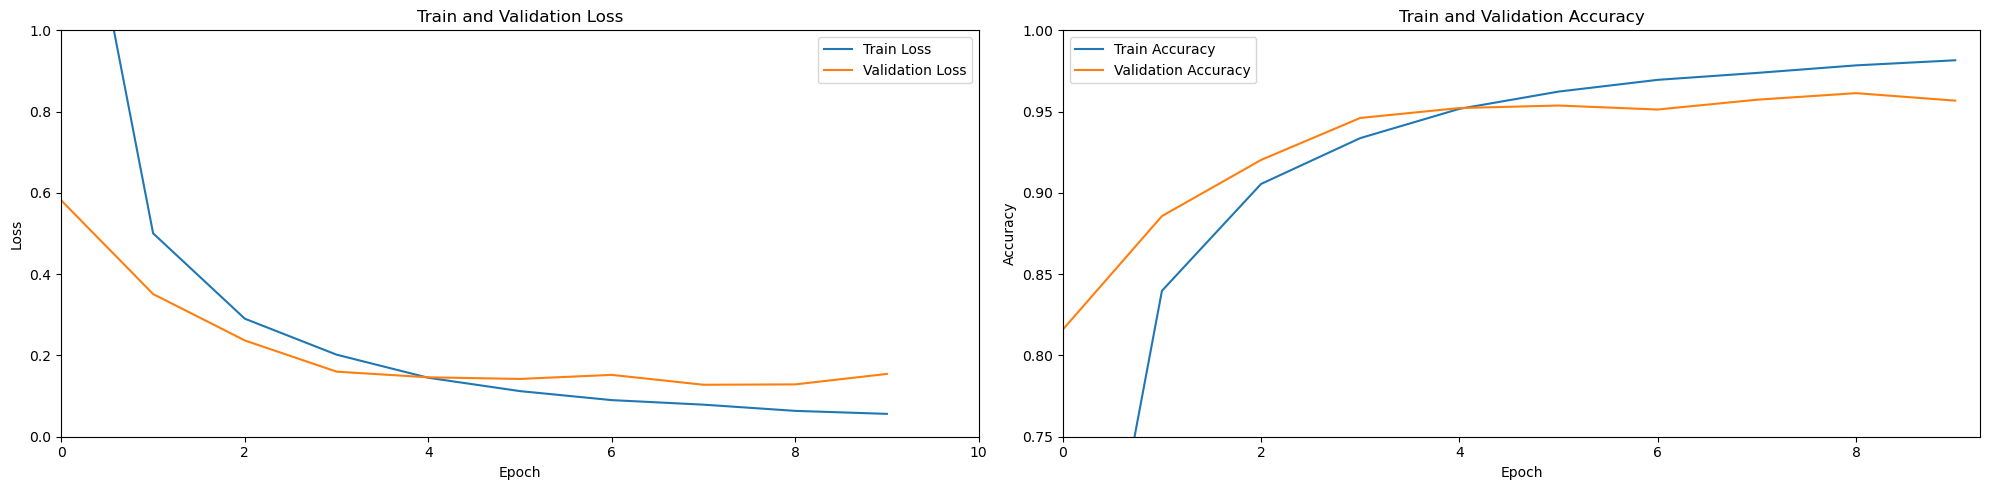

In [31]:
plt.figure(figsize = (20,5))
plt.subplot(1,2,1)
plt.title("Train and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(history.history['loss'],label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlim(0, 10)
plt.ylim(0.0,1.0)
plt.legend()

plt.subplot(1,2,2)
plt.title("Train and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlim(0, 9.25)
plt.ylim(0.75,1.0)
plt.legend()
plt.tight_layout()

In [65]:
labels = []
predictions = []
for x,y in test_gen:
    labels.append(list(y.numpy()))
    predictions.append(tf.argmax(model.predict(x),1).numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 41s 41s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

In [79]:
predictions = list(predictions)
labels = list(labels)

In [81]:
print("Train Accuracy  : {:.2f} %".format(history.history['accuracy'][-1]*100))
print("Test Accuracy   : {:.2f} %".format(accuracy_score(labels, predictions) * 100))
print("Precision Score : {:.2f} %".format(precision_score(labels, predictions, average='micro') * 100))
print("Recall Score    : {:.2f} %".format(recall_score(labels, predictions, average='micro') * 100))

Train Accuracy  : 98.16 %
Test Accuracy   : 95.67 %
Precision Score : 95.67 %
Recall Score    : 95.67 %


In [87]:

from sklearn.metrics import ConfusionMatrixDisplay

<Figure size 2000x500 with 0 Axes>

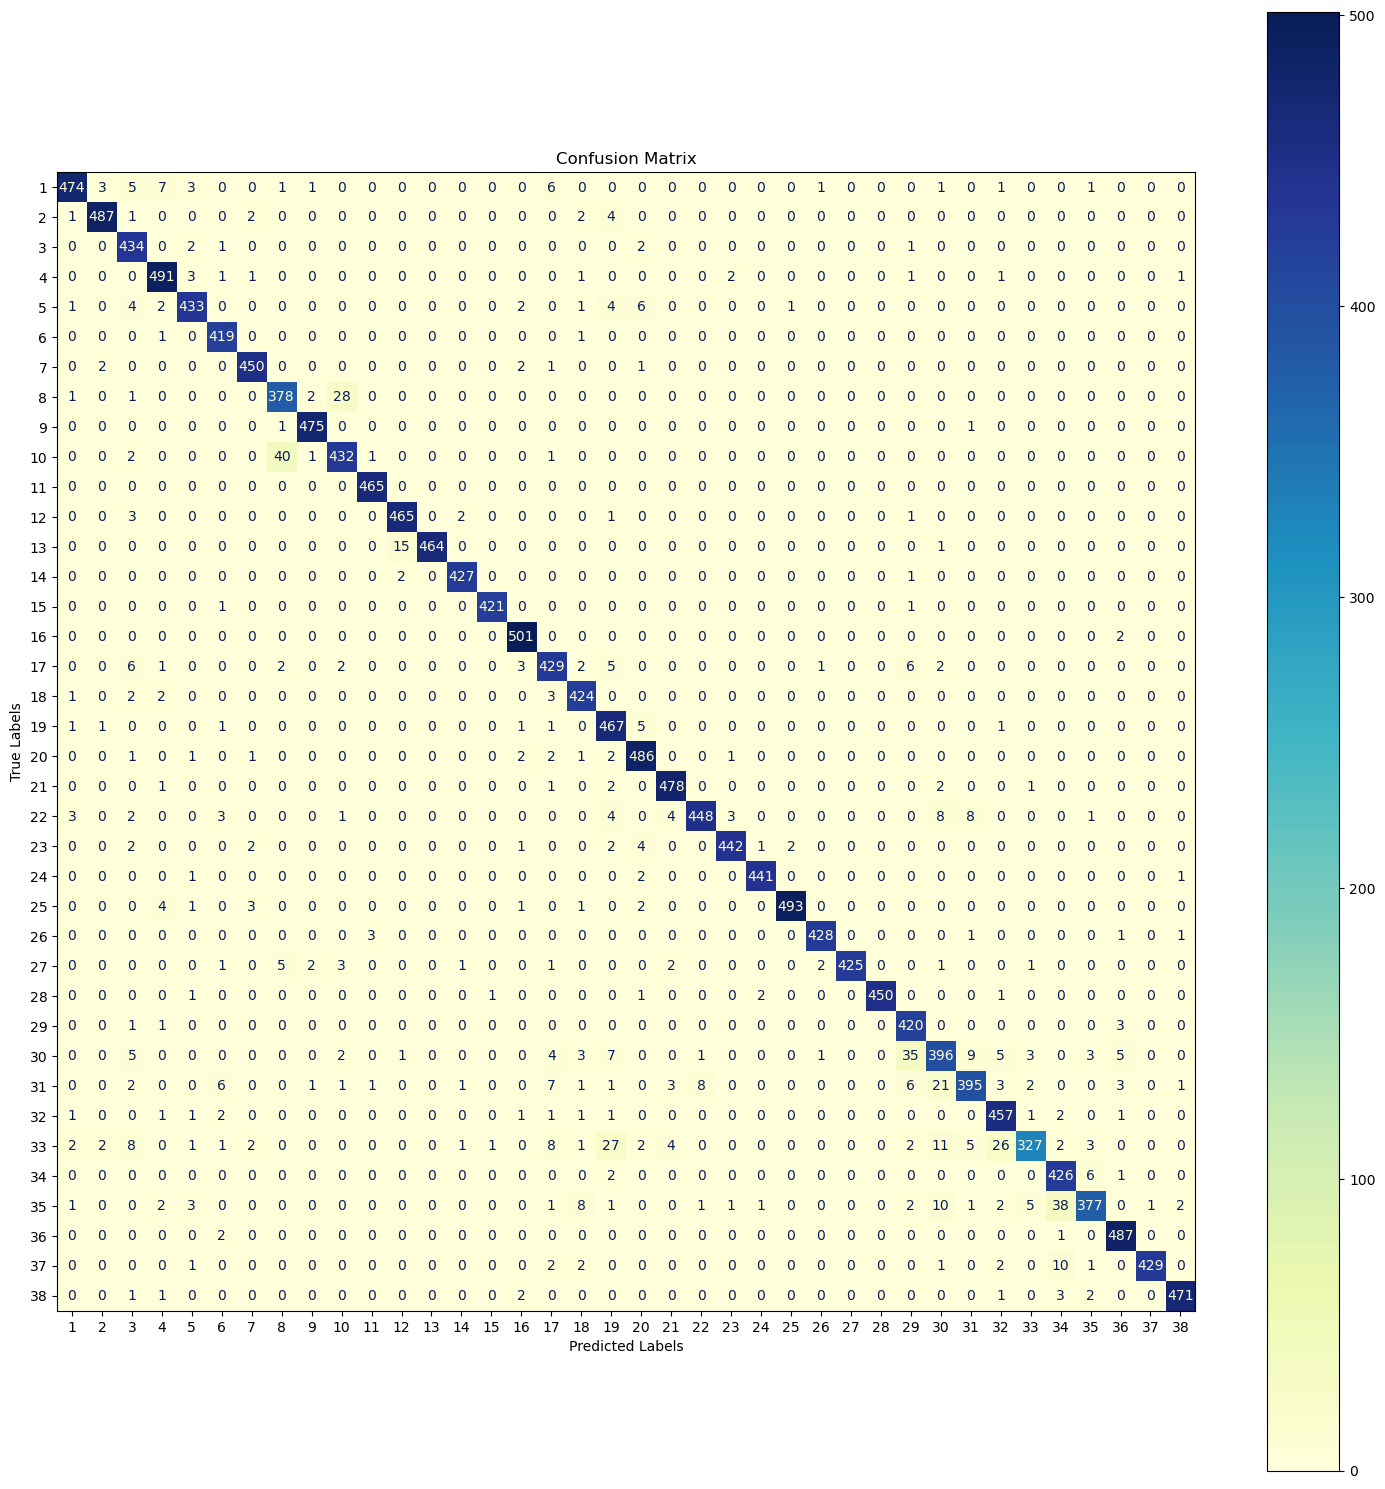

In [89]:
plt.figure(figsize=(20,5))
cm = confusion_matrix(labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=list(range(1,39)))
fig, ax = plt.subplots(figsize=(15,15))
disp.plot(ax=ax, cmap='YlGnBu', colorbar=True)
plt.title("Confusion Matrix")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()

<h3>Confusion Matrix</h3>